In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/shoes_shoes41.jpg
/kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/biological_biological162.jpg
/kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/clothes_clothes5254.jpg
/kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/shoes_shoes_1218.jpg
/kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/biological_biological_117.jpg
/kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/clothes_clothes_1706.jpg
/kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/shoes_shoes_1012.jpg
/kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/biological_biological_27.jpg
/kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test

# Waste Classification Model Training

This notebook retrains an **EfficientNetB0** model to classify waste as **recyclable** or **non-recyclable**, addressing the issue of all predictions being "non-recyclable." We include:

- 📸 **Sample Images**: Visualize one image from each class.
- 📊 **Class Distribution**: Check for imbalance.
- 🧠 **Two-Stage Training**: Initial training with frozen layers, then fine-tuning top layers.
- 📈 **Rich Metrics**: Accuracy, loss, confusion matrix, ROC curve, precision-recall curve.
- ✅ **Testing**: Predictions with bounding boxes on the test set.

**Dataset**:
- **Train**: `/Users/aditya/Desktop/Waste Dataset/train`
  - `recyclable`
  - `non-recyclable`
- **Test**: `/Users/aditya/Desktop/Waste Dataset/test`
  - `recyclable`
  - `non-recyclable`

Let’s create a stunning and insightful notebook!

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import random
from tqdm.notebook import tqdm
import pandas as pd

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Set seaborn style for beautiful plots
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Setup complete!")

Setup complete!


## Sample Images from Dataset

Let's take a look at one image from each class to understand our data.

Displaying sample images...


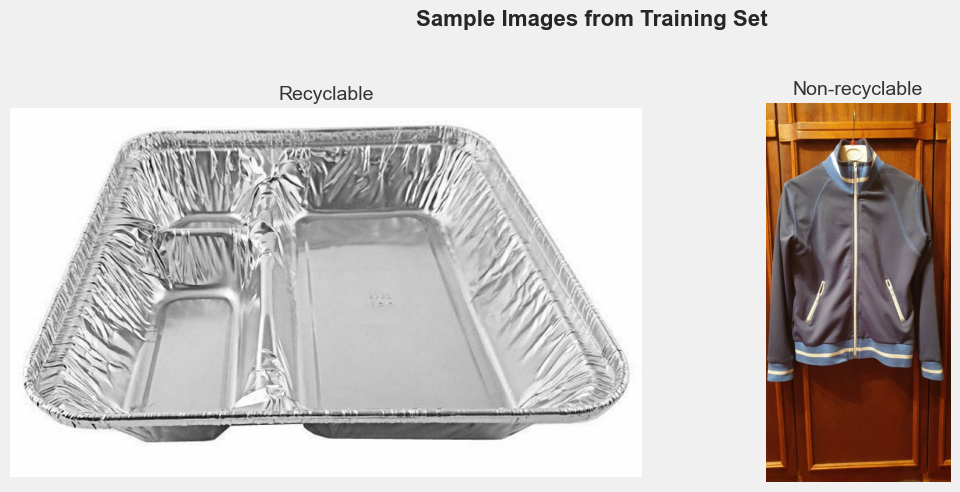

In [3]:
def display_sample_images(train_dir):
    subfolders = ["recyclable", "non-recyclable"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='#f0f0f0')
    fig.suptitle('Sample Images from Training Set', fontsize=16, fontweight='bold')

    for i, subfolder in enumerate(subfolders):
        subfolder_path = os.path.join(train_dir, subfolder)
        if not os.path.isdir(subfolder_path):
            print(f"Warning: {subfolder_path} not found.")
            continue

        image_files = [f for f in os.listdir(subfolder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        if not image_files:
            print(f"No images in {subfolder_path}.")
            continue

        random_image = random.choice(image_files)
        image_path = os.path.join(subfolder_path, random_image)
        img = cv2.imread(image_path)
        if img is None:
            print(f"Error loading {image_path}.")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img)
        axes[i].set_title(subfolder.capitalize(), fontsize=14, color='#333333')
        axes[i].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

train_dir = "/Users/aditya/Desktop/Explo_Dataset/train"
test_dir = "/Users/aditya/Desktop/Explo_Dataset/test"

print("Displaying sample images...")
display_sample_images(train_dir)

## Class Distribution

Let's check the number of images in each class to identify any imbalance.

Plotting class distribution...
Class counts: {'recyclable': 11222, 'non-recyclable': 14779}


/var/folders/cc/xc7z27h17_ddch3zr_81k6tw0000gn/T/ipykernel_2560/4115563006.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=df, palette='Blues_d')


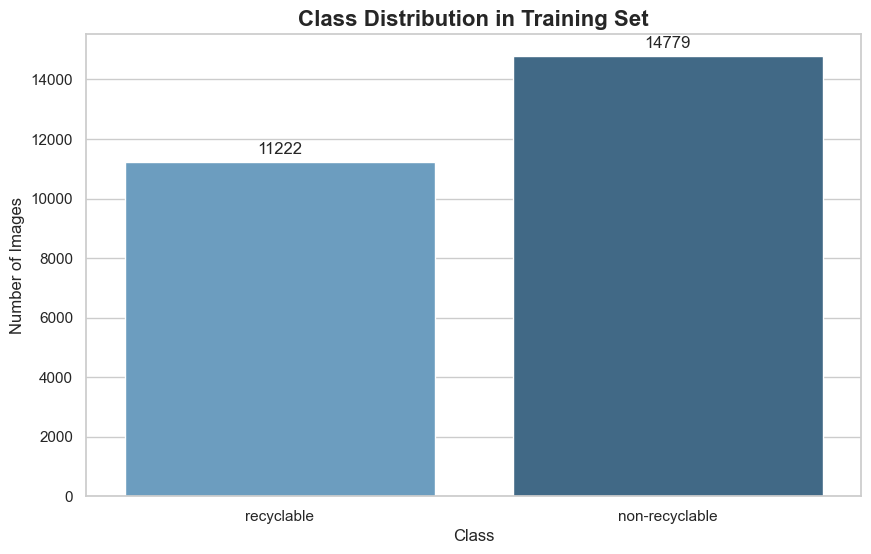

In [6]:
def plot_class_distribution(train_dir):
    subfolders = ["recyclable", "non-recyclable"]
    counts = []

    for subfolder in subfolders:
        subfolder_path = os.path.join(train_dir, subfolder)
        if os.path.isdir(subfolder_path):
            image_files = [f for f in os.listdir(subfolder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            counts.append(len(image_files))
        else:
            counts.append(0)

    print(f"Class counts: {dict(zip(subfolders, counts))}")
    df = pd.DataFrame({'Class': subfolders, 'Count': counts})
    sns.barplot(x='Class', y='Count', data=df, palette='Blues_d')
    plt.title('Class Distribution in Training Set', fontsize=16, fontweight='bold')
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    for i, count in enumerate(counts):
        plt.text(i, count + max(counts)*0.02, str(count), ha='center', fontsize=12)
    plt.show()

print("Plotting class distribution...")
plot_class_distribution(train_dir)

## Model Training

We'll train an EfficientNetB0 model with:
- Data augmentation to balance classes.
- Class weights to handle imbalance.
- 10 epochs with Adam optimizer.
- Metrics: accuracy, loss, and validation performance.

In [9]:
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

try:
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(380, 380),
        batch_size=32,
        class_mode='binary',
        shuffle=True
    )

    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(380, 380),
        batch_size=32,
        class_mode='binary',
        shuffle=False
    )
except Exception as e:
    print(f"Error loading data: {e}")
    exit()

print(f"Class indices: {train_generator.class_indices}")

Found 26001 images belonging to 2 classes.
Found 6908 images belonging to 2 classes.
Class indices: {'non-recyclable': 0, 'recyclable': 1}


In [29]:
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(380, 380),
    batch_size=32,
    class_mode='binary'
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(380, 380),
    batch_size=32,
    class_mode='binary'
)


Found 26001 images belonging to 2 classes.
Found 6908 images belonging to 2 classes.


In [31]:
classes = np.array([0, 1])
y = train_generator.classes
try:
    class_weights = compute_class_weight('balanced', classes=classes, y=y)
    class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
    print(f"Class weights: {class_weight_dict}")
except Exception as e:
    print(f"Error computing class weights: {e}")
    class_weight_dict = None

Class weights: {0: 0.8796603288449828, 1: 1.1584833363036893}


In [49]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(380, 380, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [51]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 12, 12, 1280)   │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [25]:
print("Initial training...")
history_initial = model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator,
    class_weight=class_weight_dict,
    callbacks=[tf.keras.callbacks.LambdaCallback(
        on_epoch_begin=lambda epoch, logs: tqdm.write(f"Epoch {epoch + 1}/5")
    )]
)

Initial training...
Epoch 1/5
Epoch 1/5


/opt/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-04-20 17:16:07.651232: W tensorflow/core/framework/op_kernel.cc:1827] INVALID_ARGUMENT: TypeError: `generator` yielded an element that did not match the expected structure. The expected structure was (tf.float32, tf.float32, tf.float32), but the yielded element was (array([[[[1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        [[1.        , 1.        , 1.        ],
       

InvalidArgumentError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
TypeError: `generator` yielded an element that did not match the expected structure. The expected structure was (tf.float32, tf.float32, tf.float32), but the yielded element was (array([[[[1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        [[1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        [[1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]

^^^^^^^^^^^^^^^^

  File "/opt/anaconda3/lib/python3.11/site-packages/tensorflow/python/util/nest_util.py", line 1570, in _tf_data_flatten_up_to
    _tf_data_assert_shallow_structure(shallow_tree, input_tree)

  File "/opt/anaconda3/lib/python3.11/site-packages/tensorflow/python/util/nest_util.py", line 1427, in _tf_data_assert_shallow_structure
    raise ValueError(

ValueError: The two structures don't have the same sequence length. Input structure has length 2, while shallow structure has length 3.


The above exception was the direct cause of the following exception:


Traceback (most recent call last):

  File "/opt/anaconda3/lib/python3.11/site-packages/tensorflow/python/ops/script_ops.py", line 270, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "/opt/anaconda3/lib/python3.11/site-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "/opt/anaconda3/lib/python3.11/site-pa

In [17]:
model.save('/kaggle/working/initial_model.keras')
print("Model saved as '/kaggle/working/initial_model.keras'")

Model saved as '/kaggle/working/initial_model.keras'


In [19]:

base_model.trainable = True
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])

In [20]:
history_fine = model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator,
    class_weight=class_weight_dict,
    callbacks=[tf.keras.callbacks.LambdaCallback(
        on_epoch_begin=lambda epoch, logs: tqdm.write(f"Epoch {epoch + 1}/5")
    )]
)

Epoch 1/5
Epoch 1/5


E0000 00:00:1744623434.539472     110 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1744623434.747099     110 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


329/813 ━━━━━━━━━━━━━━━━━━━━ 8:12 1s/step - accuracy: 0.9617 - loss: 0.0961

E0000 00:00:1744623779.676794     113 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1744623779.886000     113 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


813/813 ━━━━━━━━━━━━━━━━━━━━ 921s 1s/step - accuracy: 0.9698 - loss: 0.0783 - val_accuracy: 0.9917 - val_loss: 0.0252
Epoch 2/5
Epoch 2/5
813/813 ━━━━━━━━━━━━━━━━━━━━ 878s 1s/step - accuracy: 0.9839 - loss: 0.0398 - val_accuracy: 0.9932 - val_loss: 0.0210
Epoch 3/5
Epoch 3/5
813/813 ━━━━━━━━━━━━━━━━━━━━ 865s 1s/step - accuracy: 0.9892 - loss: 0.0299 - val_accuracy: 0.9942 - val_loss: 0.0177
Epoch 4/5
Epoch 4/5
813/813 ━━━━━━━━━━━━━━━━━━━━ 873s 1s/step - accuracy: 0.9876 - loss: 0.0314 - val_accuracy: 0.9946 - val_loss: 0.0149
Epoch 5/5
Epoch 5/5
813/813 ━━━━━━━━━━━━━━━━━━━━ 884s 1s/step - accuracy: 0.9908 - loss: 0.0255 - val_accuracy: 0.9958 - val_loss: 0.0141


In [21]:
history = {
    'accuracy': history_initial.history['accuracy'] + history_fine.history['accuracy'],
    'val_accuracy': history_initial.history['val_accuracy'] + history_fine.history['val_accuracy'],
    'loss': history_initial.history['loss'] + history_fine.history['loss'],
    'val_loss': history_initial.history['val_loss'] + history_fine.history['val_loss']
}

In [23]:
model.save('/kaggle/working/updated_model.keras')
print("Model saved as /kaggle/working/updated_model.keras")

Model saved as /kaggle/working/updated_model.keras


## Training Metrics

- 📈 Accuracy/loss curves.
- 🔢 Confusion matrix.
- 📉 ROC curve.
- ⚖️ Precision-recall curve.

In [26]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

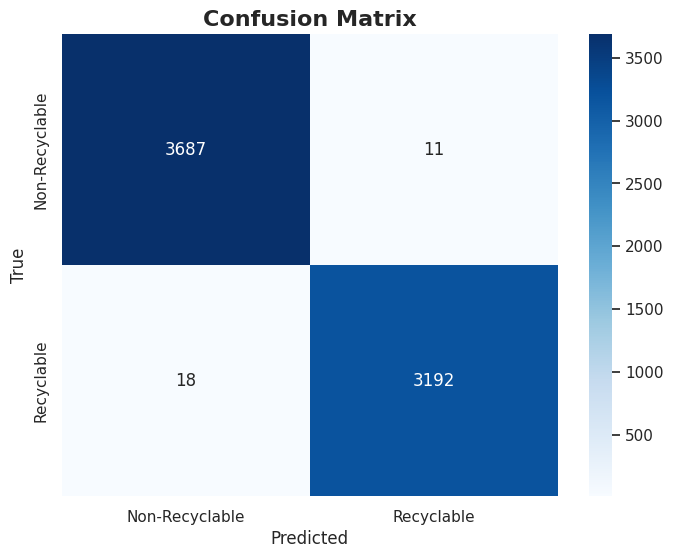

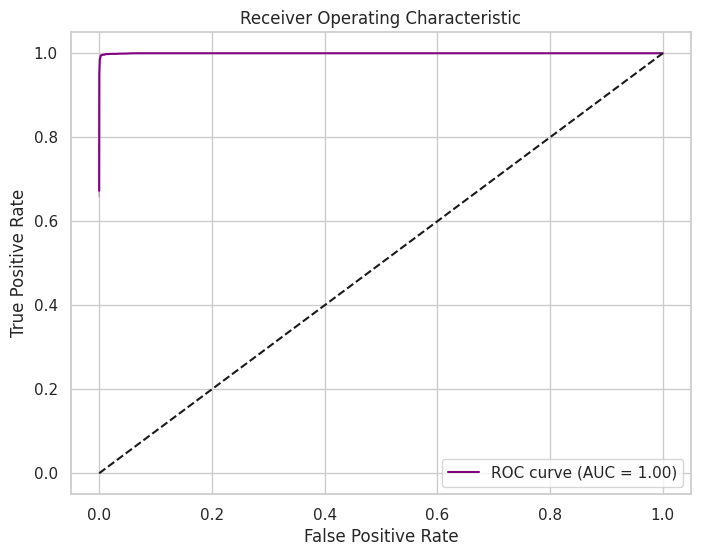

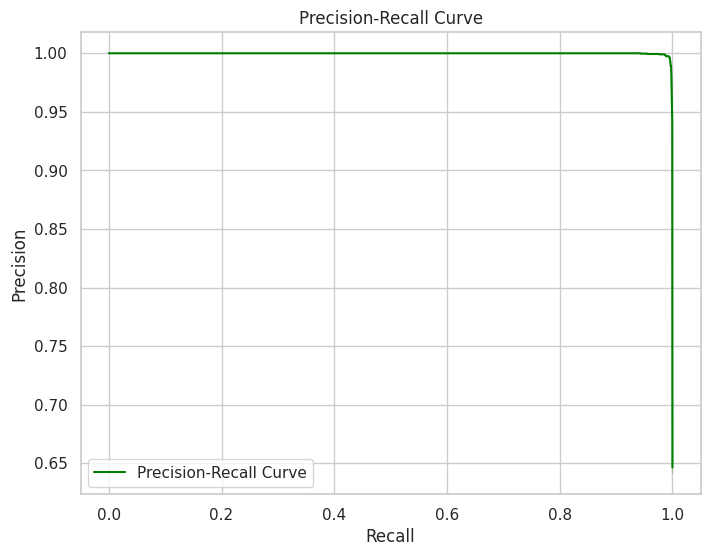

In [27]:
test_generator.reset()
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Recyclable', 'Recyclable'], yticklabels=['Non-Recyclable', 'Recyclable'])
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr, y=tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', color='purple')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Receiver Operating Characteristic')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

precision, recall, _ = precision_recall_curve(y_true, y_pred_probs)
plt.figure(figsize=(8, 6))
sns.lineplot(x=recall, y=precision, label='Precision-Recall Curve', color='green')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

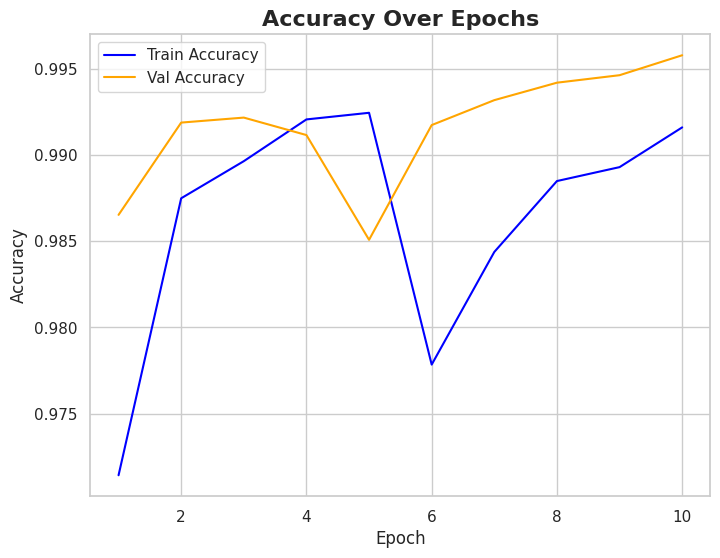

In [32]:
# Accuracy plot
plt.figure(figsize=(8, 6))
sns.lineplot(x=range(1, len(history['accuracy']) + 1), y=history['accuracy'], label='Train Accuracy', color='blue')
sns.lineplot(x=range(1, len(history['val_accuracy']) + 1), y=history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Accuracy Over Epochs', fontsize=16, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('/kaggle/working/accuracy_plot.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

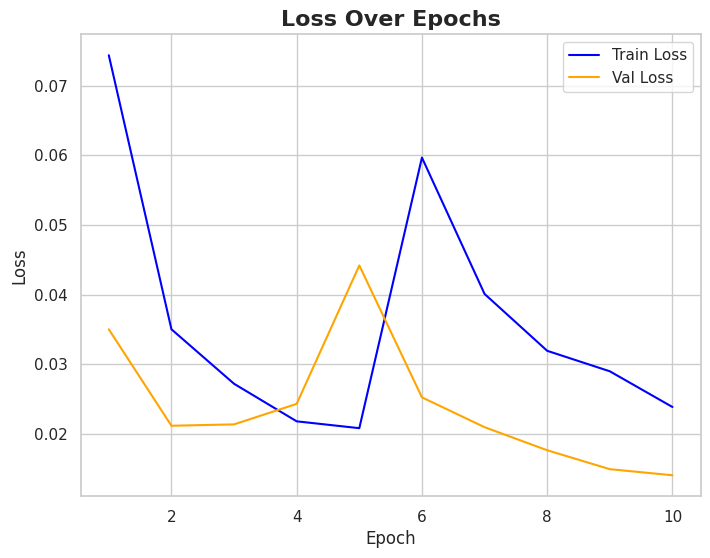

In [33]:
# Loss plot
plt.figure(figsize=(8, 6))
sns.lineplot(x=range(1, len(history['loss']) + 1), y=history['loss'], label='Train Loss', color='blue')
sns.lineplot(x=range(1, len(history['val_loss']) + 1), y=history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss Over Epochs', fontsize=16, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('/kaggle/working/loss_plot.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

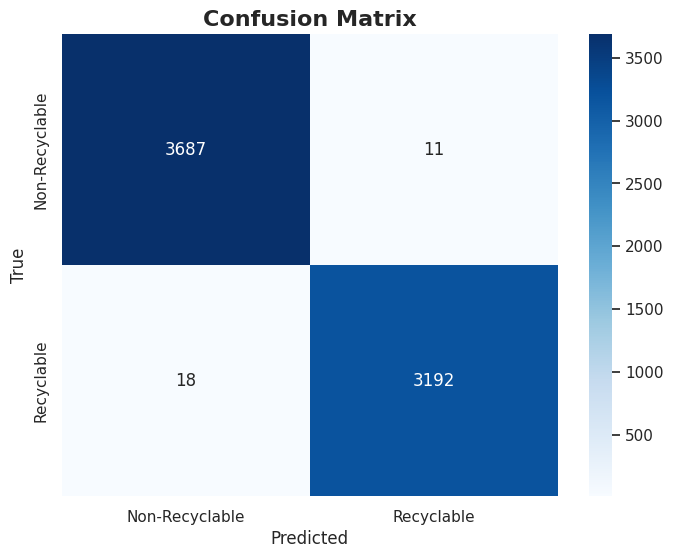

In [34]:
# Confusion Matrix
test_generator.reset()
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Recyclable', 'Recyclable'], yticklabels=['Non-Recyclable', 'Recyclable'])
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

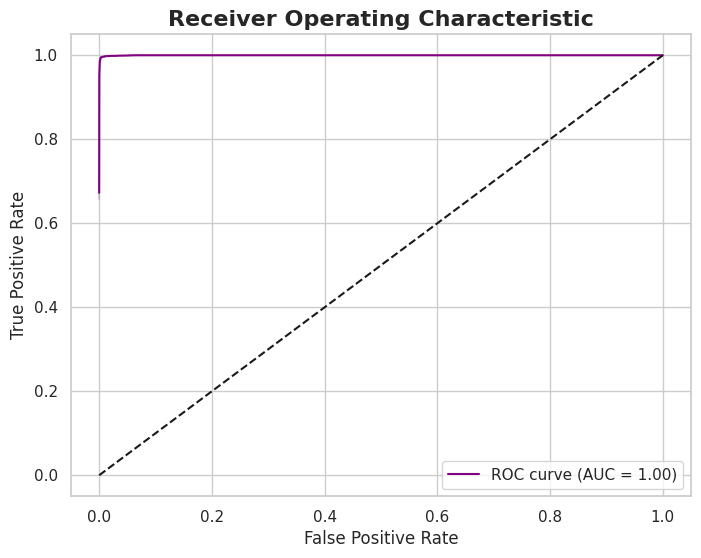

In [35]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr, y=tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', color='purple')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Receiver Operating Characteristic', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig('/kaggle/working/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

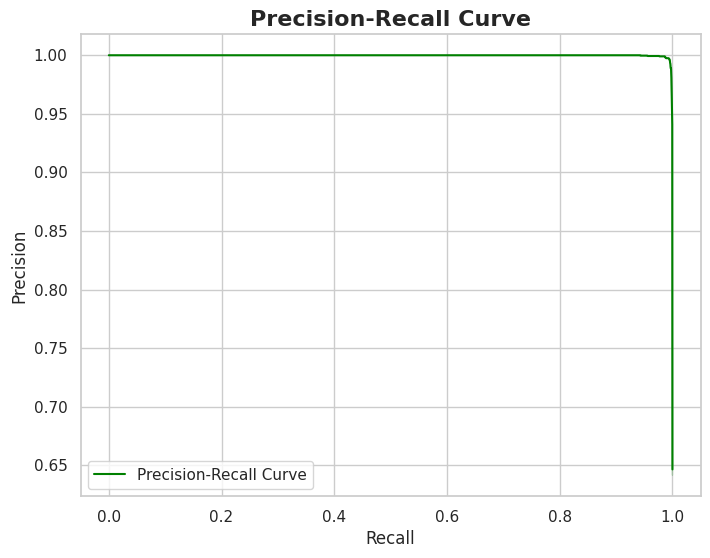

In [36]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_pred_probs)
plt.figure(figsize=(8, 6))
sns.lineplot(x=recall, y=precision, label='Precision-Recall Curve', color='green')
plt.title('Precision-Recall Curve', fontsize=16, fontweight='bold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.savefig('/kaggle/working/precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## Test Predictions

Testing 10 images per class to verify predictions.

Processing subfolders:   0%|          | 0/2 [00:00<?, ?it/s]

Processing recyclable:   0%|          | 0/10 [00:00<?, ?it/s]

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/recyclable/cardboard_cardboard_767.jpg
Ground truth: recyclable
Predicted: recyclable, Confidence: 1.0000
Output saved as /kaggle/working/output_recyclable_cardboard_cardboard_767.jpg



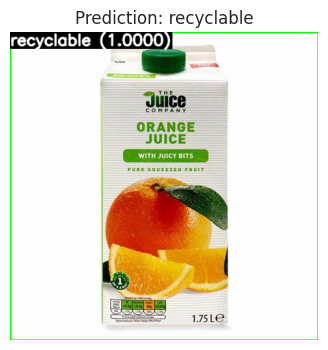

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/recyclable/metal_metal623.jpg
Ground truth: recyclable
Predicted: recyclable, Confidence: 1.0000
Output saved as /kaggle/working/output_recyclable_metal_metal623.jpg



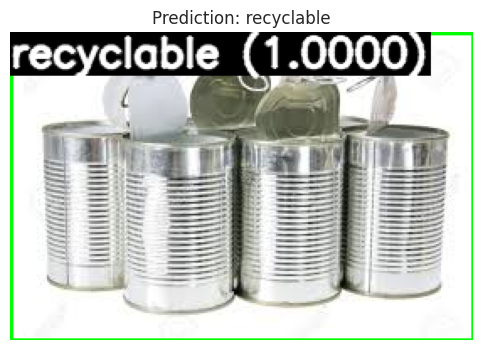

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/recyclable/cardboard_cardboard228.jpg
Ground truth: recyclable
Predicted: recyclable, Confidence: 0.9684
Output saved as /kaggle/working/output_recyclable_cardboard_cardboard228.jpg



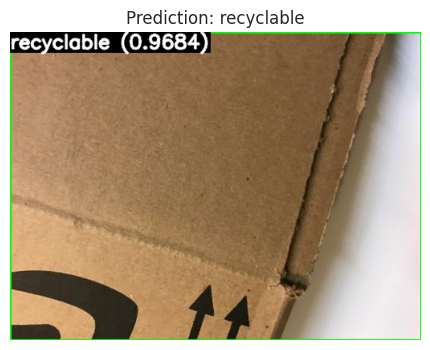

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/recyclable/plastic_plastic_1523.jpg
Ground truth: recyclable
Predicted: recyclable, Confidence: 1.0000
Output saved as /kaggle/working/output_recyclable_plastic_plastic_1523.jpg



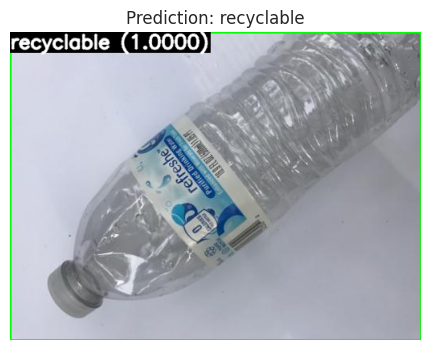

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/recyclable/paper_paper393.jpg
Ground truth: recyclable
Predicted: recyclable, Confidence: 0.9719
Output saved as /kaggle/working/output_recyclable_paper_paper393.jpg



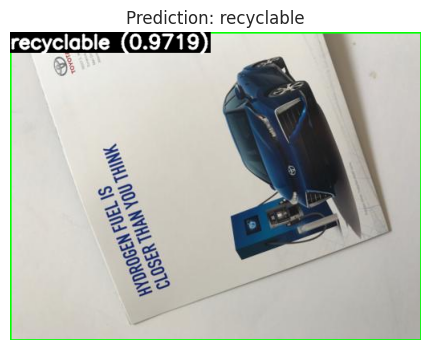

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/recyclable/glass_glass363.jpg
Ground truth: recyclable
Predicted: recyclable, Confidence: 1.0000
Output saved as /kaggle/working/output_recyclable_glass_glass363.jpg



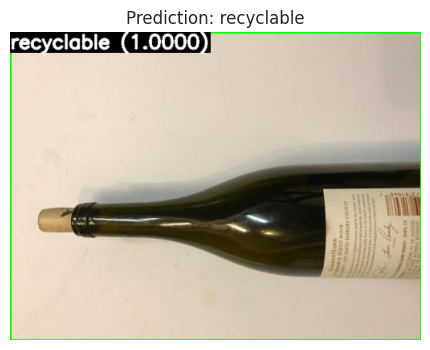

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/recyclable/cardboard_cardboard507.jpg
Ground truth: recyclable
Predicted: recyclable, Confidence: 0.9872
Output saved as /kaggle/working/output_recyclable_cardboard_cardboard507.jpg



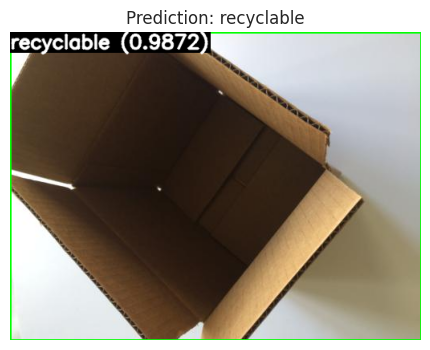

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/recyclable/cardboard_cardboard_1038.jpg
Ground truth: recyclable
Predicted: recyclable, Confidence: 1.0000
Output saved as /kaggle/working/output_recyclable_cardboard_cardboard_1038.jpg



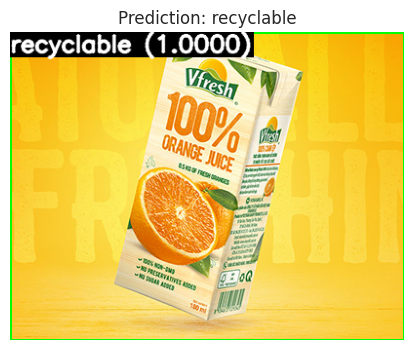

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/recyclable/paper_paper_1501.jpg
Ground truth: recyclable
Predicted: recyclable, Confidence: 0.9996
Output saved as /kaggle/working/output_recyclable_paper_paper_1501.jpg



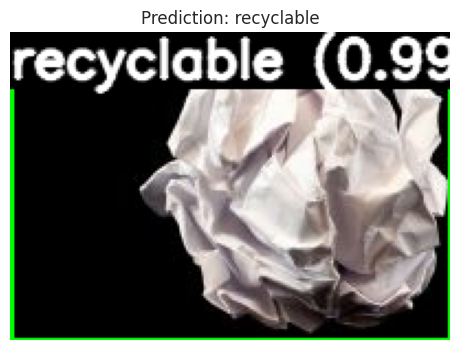

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/recyclable/plastic_plastic_2515.jpg
Ground truth: recyclable
Predicted: recyclable, Confidence: 1.0000
Output saved as /kaggle/working/output_recyclable_plastic_plastic_2515.jpg



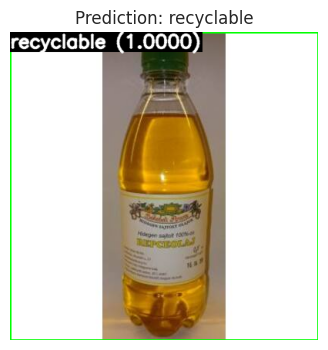

Processing non-recyclable:   0%|          | 0/10 [00:00<?, ?it/s]

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/shoes_shoes41.jpg
Ground truth: non-recyclable
Predicted: non-recyclable, Confidence: 0.0000
Output saved as /kaggle/working/output_non-recyclable_shoes_shoes41.jpg



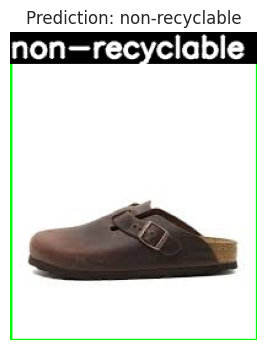

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/biological_biological162.jpg
Ground truth: non-recyclable
Predicted: non-recyclable, Confidence: 0.0015
Output saved as /kaggle/working/output_non-recyclable_biological_biological162.jpg



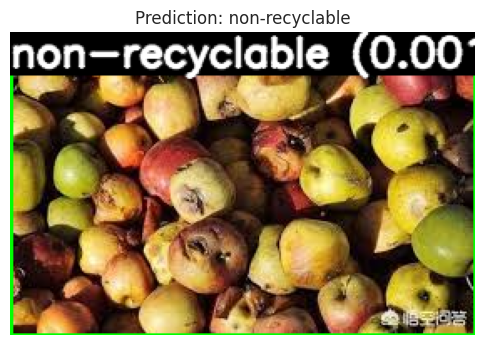

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/clothes_clothes5254.jpg
Ground truth: non-recyclable
Predicted: non-recyclable, Confidence: 0.0000
Output saved as /kaggle/working/output_non-recyclable_clothes_clothes5254.jpg



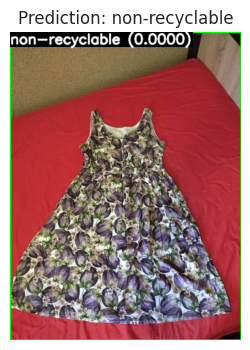

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/shoes_shoes_1218.jpg
Ground truth: non-recyclable
Predicted: non-recyclable, Confidence: 0.0008
Output saved as /kaggle/working/output_non-recyclable_shoes_shoes_1218.jpg



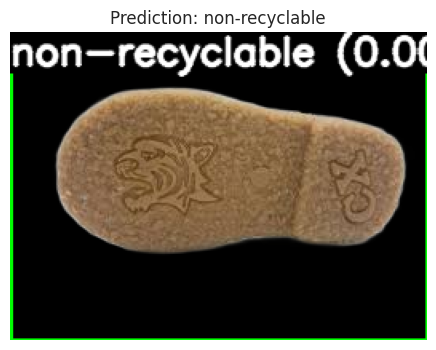

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/biological_biological_117.jpg
Ground truth: non-recyclable
Predicted: Uncertain, Confidence: 0.4480
Output saved as /kaggle/working/output_non-recyclable_biological_biological_117.jpg



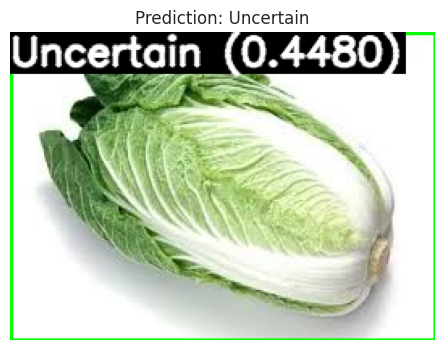

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/clothes_clothes_1706.jpg
Ground truth: non-recyclable
Predicted: non-recyclable, Confidence: 0.0000
Output saved as /kaggle/working/output_non-recyclable_clothes_clothes_1706.jpg



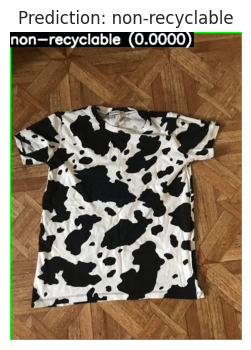

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/shoes_shoes_1012.jpg
Ground truth: non-recyclable
Predicted: non-recyclable, Confidence: 0.0000
Output saved as /kaggle/working/output_non-recyclable_shoes_shoes_1012.jpg



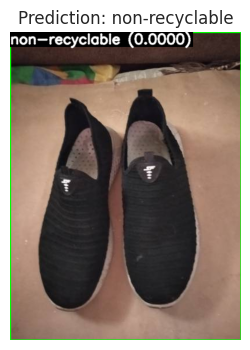

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/biological_biological_27.jpg
Ground truth: non-recyclable
Predicted: non-recyclable, Confidence: 0.0256
Output saved as /kaggle/working/output_non-recyclable_biological_biological_27.jpg



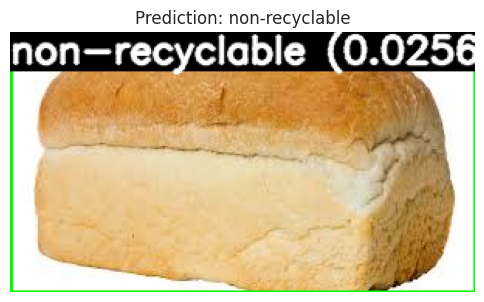

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/shoes_shoes_118.jpg
Ground truth: non-recyclable
Predicted: non-recyclable, Confidence: 0.0411
Output saved as /kaggle/working/output_non-recyclable_shoes_shoes_118.jpg



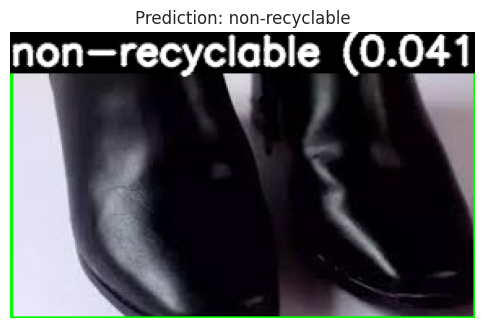

Image: /kaggle/input/waste-datasetrecyclable-and-non-recyclable/Explo_Dataset/test/non-recyclable/biological_biological_752.jpg
Ground truth: non-recyclable
Predicted: non-recyclable, Confidence: 0.0000
Output saved as /kaggle/working/output_non-recyclable_biological_biological_752.jpg



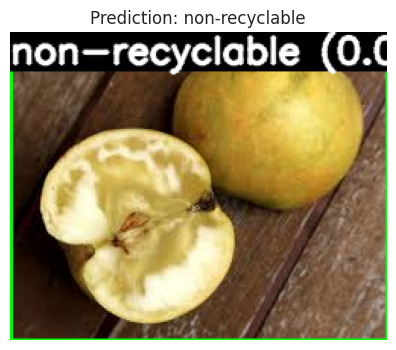


Test Results:
Total images: 20
Correct predictions: 19
Accuracy: 95.00%


In [31]:
from tensorflow.keras.preprocessing.image import img_to_array  # Ensure this is included

def process_image(image_path, ground_truth_label):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not load {image_path}.")
        return None, None, None

    frame = image.copy()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    fgbg = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=50)
    fgmask = fgbg.apply(gray)
    contours, _ = cv2.findContours(fgmask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    best_contour = None
    max_area = 0
    class_labels = ["non-recyclable", "recyclable"]

    for contour in contours:
        area = cv2.contourArea(contour)
        if area > 5000:
            x, y, w, h = cv2.boundingRect(contour)
            aspect_ratio = float(w) / h
            if 0.5 < aspect_ratio < 2.0 and area > max_area:
                max_area = area
                best_contour = contour

    if best_contour is not None:
        x, y, w, h = cv2.boundingRect(best_contour)
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        object_img = frame[y:y + h, x:x + w]
    else:
        print(f"No object detected in {image_path}. Using whole image.")
        object_img = frame

    try:
        object_img = cv2.resize(object_img, (380, 380))
        object_img = img_to_array(object_img)
        object_img = np.expand_dims(object_img, axis=0)
        object_img = tf.keras.applications.efficientnet.preprocess_input(object_img)

        predictions = model.predict(object_img, verbose=0)
        confidence = predictions[0][0]
        if confidence > 0.7:
            predicted_label = class_labels[1]
        elif confidence < 0.3:
            predicted_label = class_labels[0]
        else:
            predicted_label = "Uncertain"

        # Debug print for each prediction
        print(f"Image: {image_path}")
        print(f"Ground truth: {ground_truth_label}")
        print(f"Predicted: {predicted_label}, Confidence: {confidence:.4f}")
        if predicted_label != ground_truth_label and predicted_label != "Uncertain":
            print(f"*** MISCLASSIFIED ***")

        text = f"{predicted_label} ({confidence:.4f})"
        text_y = max(20, 50 if best_contour is None else y - 10)
        x_text = 50 if best_contour is None else x
        text_size, _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
        text_w, text_h = text_size
        cv2.rectangle(frame, (x_text, text_y - text_h - 5), (x_text + text_w, text_y + 5), (0, 0, 0), -1)
        cv2.putText(frame, text, (x_text, text_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)

        return frame, predicted_label, confidence
    except Exception as e:
        print(f"Error during prediction for {image_path}: {e}")
        return None, None, None

total_images = 0
correct_predictions = 0
misclassified = []

for subfolder in tqdm(["recyclable", "non-recyclable"], desc="Processing subfolders"):
    subfolder_path = os.path.join(test_dir, subfolder)
    if not os.path.isdir(subfolder_path):
        print(f"Warning: {subfolder_path} not found.")
        continue

    ground_truth_label = subfolder
    image_files = [f for f in os.listdir(subfolder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    for image_file in tqdm(image_files[:10], desc=f"Processing {subfolder}", leave=False):
        image_path = os.path.join(subfolder_path, image_file)
        total_images += 1

        result, predicted_label, confidence = process_image(image_path, ground_truth_label)
        if result is None:
            continue

        if predicted_label == ground_truth_label:
            correct_predictions += 1
        elif predicted_label != "Uncertain":
            misclassified.append((image_path, ground_truth_label, predicted_label, confidence))

        output_path = os.path.join("/kaggle/working", f"output_{subfolder}_{image_file}")
        try:
            cv2.imwrite(output_path, result)
            print(f"Output saved as {output_path}\n")
        except Exception as e:
            print(f"Error saving {output_path}: {e}")

        img_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 4))
        plt.imshow(img_rgb)
        plt.title(f"Prediction: {predicted_label}", fontsize=12)
        plt.axis('off')
        plt.show()

accuracy = (correct_predictions / total_images) * 100 if total_images > 0 else 0
print(f"\nTest Results:")
print(f"Total images: {total_images}")
print(f"Correct predictions: {correct_predictions}")
print(f"Accuracy: {accuracy:.2f}%")

if misclassified:
    print("\nMisclassified images:")
    for img_path, gt, pred, conf in misclassified:
        print(f"Image: {img_path}")
        print(f"Ground truth: {gt}, Predicted: {pred}, Confidence: {conf:.4f}")